In [1]:
import pandas as pd
import os 
from datetime import datetime
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [2]:
### Dados Brutos (Com coluna de Estatistica)

dados = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutos.xlsx')

metadados = ['Data', 'Estatistica'] # Armazena as colunas com dados de identificacao numa lista. Pode ser expandida caso necessario

variaveis = [cols for cols in dados.columns if cols not in metadados]   # Armazena as colunas com os dados das variaveis numa lista com todas as colunas, exceto as incluidas em "metadados"

# print(variaveis)

# dados.info

<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\595763524.py:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  dados = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutos.xlsx')


In [3]:
### Dados Brutos Prontos (Estatisticas Pivotadas)

dados_prontos = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutosProntos.xlsx')

<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\3449656471.py:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  dados_prontos = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutosProntos.xlsx')


In [4]:
describe = dados.describe(include='all')    # Armazena as estatisticas do describe numa variavel de mesmo nome. O include='all' garante que todas as colunas serao incluidas

# describe['Totais'] = describe[dados.sum(axis=1) if str(dados.dt).startswith() != float else describe]

# print(describe)

# Dados Ausentes

In [5]:
### Dados Ausentes

def calculate_missing_percentage(df1, df2):
    """
    Função que calcula as quantidades e porcentagens de dados faltantes
    por coluna, retornando linhas ao final do dataframe com as estatísticas
    do banco de dados contendo esses valores.
    """
    missing_by_column = df1.isna().sum()    # Soma a quantidade de dados faltantes por coluna
    total_rows = len(df1)   # Conta a quantidade de linhas no dataframe
    missing_percentage_by_column = (missing_by_column / total_rows * 100).round(2)  # Calcula a porcentagem de dados faltantes por coluna, a partir dos 2 passos anteriores
    missing_total = df1.isna().sum().sum()  # Calcula o número total de dados faltantes no dataframe
    total_elements = total_rows * len(variaveis)   # Calcula o total de "células" presentes no banco de dados
    missing_percentage_total = (missing_total / total_elements * 100).round(2)  # Calcula a porcentagem de dados faltantes no dataframe a partir dos 2 passos anteriores
    df2.loc["Porcentagem de Dados Faltantes"] = missing_percentage_by_column    # Gera a linha com porcentagem de dados faltantes por coluna
    df2.loc["Numero de Dados Faltantes"] = missing_by_column    # Gera a linha com a contagem de dados faltantes por coluna
    return {
        'by_column': missing_percentage_by_column,
        'total': missing_percentage_total
    }

In [6]:
calculate_missing_percentage(dados, describe)

{'by_column': Data              0.00
 Estatistica       0.00
 COR               0.52
 TURB.             0.52
 pH                0.52
 ALC.              5.21
 AC.               5.21
 O.C.              3.65
 DBO              96.35
 O.D.              2.78
 Cl                3.65
 DUR.              3.65
 Fe                3.65
 Mn                3.65
 N                89.06
 P                90.62
 Cond.             1.56
 Amonia           75.52
 Surfact.         99.48
 Cianobacteria     7.29
 S.T.             99.48
 C.T.             60.94
 C.F.             19.79
 Clorofila         7.81
 F                18.75
 Fenol            99.48
 dtype: float64,
 'total': np.float64(33.3)}

# Dados não numéricos

In [7]:
dados.select_dtypes(exclude= float)   # Permite identificar colunas com valores nao numericos. 
                                            # No caso, sao elas "Data" e "data_normalizada" (esperado), 
                                            # mas tambem "C.F. Max.", "Fenol_Max.", "Fenol_Med." e "Fenol_Min."
                                            # Isso ocorre, pois essas colunas apresentam células com os caracteres "<" ou ">"

,Data,Estatistica,C.F.,Fenol
0,2009-01-01,Min.,23000,NaN
1,2009-01-01,Med.,23000,NaN
2,2009-01-01,Max.,23000,NaN
3,2009-02-01,Min.,30000,NaN
4,2009-02-01,Med.,30000,NaN
...,...,...,...,...
571,2024-11-01,Med.,3000,NaN
572,2024-11-01,Max.,3000,NaN
573,2024-12-01,Min.,NaN,NaN
574,2024-12-01,Med.,NaN,NaN


Tratando dados não numéricos como "corrompidos"

In [8]:
### Dados Corrompidos

def corrupted_data(df1, df2, variaveis):
    """
    Função que calcula a quantidade de dados corrompidos, similar à dos dados faltantes,
    mas contabilizando dados não numéricos, ao invés de "NaN".
    """
    contagem_corrompidos = {}   # Cria um dicionário para a contagem de dados corrompidos
    for coluna in variaveis:
        nan_original = df2.loc["Numero de Dados Faltantes", coluna]    # Busca a contagem de dados faltantes por coluna gerada pela funcao de "calculate_missing_percentage"
        coluna_corrigida = pd.to_numeric(df1[coluna], errors='coerce')   # Remove valores de dtype != float das colunas na lista "variaveis"
        nan_update = coluna_corrigida.isna().sum() # Conta os dados ausentes apos a remocao do passo anterior
        corrupted_count = nan_update - nan_original # Subtrai a quantidade de NaN apos a remocao pela quantidade de NaN originais
        contagem_corrompidos[coluna] = corrupted_count  # Cria a contagem de dados corrompidos no dicionario
    
    corrupted_by_column = pd.Series(contagem_corrompidos)   # Usa o dicionario de dados corrompidos para contar a quantidade de dados corrompidos por coluna
    total_rows = len(df1)
    corrupted_percentage_by_column = (corrupted_by_column / total_rows * 100).round(2)
    
    corrupted_total = corrupted_by_column.sum()
    total_elements = total_rows * len(variaveis)
    corrupted_percentage_total = (corrupted_total / total_elements * 100).round(2)
   
    df2.loc["Porcentagem de Dados Corrompidos"] = corrupted_percentage_by_column
    df2.loc["Numero de Dados Corrompidos"] = corrupted_by_column
    return {
        'by_column': corrupted_percentage_by_column,
        'total': corrupted_percentage_total
    }

In [9]:
corrupted_data(dados, describe, variaveis)

{'by_column': COR              0.00
 TURB.            0.00
 pH               0.00
 ALC.             0.00
 AC.              0.00
 O.C.             0.00
 DBO              0.00
 O.D.             0.00
 Cl               0.00
 DUR.             0.00
 Fe               0.00
 Mn               0.00
 N                0.00
 P                0.00
 Cond.            0.00
 Amonia           0.00
 Surfact.         0.00
 Cianobacteria    0.00
 S.T.             0.00
 C.T.             0.00
 C.F.             0.17
 Clorofila        0.00
 F                0.00
 Fenol            0.52
 dtype: float64,
 'total': np.float64(0.03)}

In [ ]:
dados.select_dtypes(exclude= float)

,Data,Estatistica,C.F.,Fenol
0,2009-01-01,Min.,23000,NaN
1,2009-01-01,Med.,23000,NaN
2,2009-01-01,Max.,23000,NaN
3,2009-02-01,Min.,30000,NaN
4,2009-02-01,Med.,30000,NaN
...,...,...,...,...
571,2024-11-01,Med.,3000,NaN
572,2024-11-01,Max.,3000,NaN
573,2024-12-01,Min.,NaN,NaN
574,2024-12-01,Med.,NaN,NaN


Tratando dados não numéricos como "dados censurados" (incompleto)

In [ ]:
# kmf = KaplanMeierFitter()

# kmf.fit(durations=dados['C.F.'], event_observed=dados[])

# Criar uma função que itere nas colunas do dataframe, selecione as com o datatpye string, e, para essas, aplique a lógica dos "eventos_observados" (TRUE/FALSE) dependendo de se a
# Linha contém um float ou uma string (talvez procurar especificamente os caracteres "<" / ">")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3268215767.py, line 3)

# Formatacao estatisticas

## Casas decimais

In [11]:
def casas_decimais(coluna):
    """
    Funcao que determina a quantidade de casas decimais utilizadas em UMA coluna
    de um banco de dados.
    Serah utilizada para padronizar o numero de casas decimais por variavel, com base
    no numero de casas decimais utilizadas no banco original.
    """
    # Elimina celulas vazias e converte todos os valores da coluna para string
    textos = coluna.dropna().astype(str)    

    # Busca celulas que contem "." 
    decimais = textos[textos.str.contains(r'\.', regex=True, na=False)] 

    if decimais.empty:
        return 0    # Colunas sem "." sao definidas como contendo 0 casas decimais
    
    n_decimais = decimais.str.split('.').str[1].str.len()

    # Retorna o valor máximo de dígitos após a casa decimal como integer
    return int(n_decimais.max())

In [ ]:
### Aplicando a funcao 

# Selecao de estatisticas cujos valores devem ser formatados. Exclui as estatisticas criadas e adicionadas a tabela, pois essas sao porcentagens ou contagens (numeros inteiros), que serao 
# padronizadas com 2 e 0 casas decimais respectivamente
estatisticas_para_formatar = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']

# Loop para iterar sobre as variaveis numericas
for col in variaveis:
    # 1. A função analisa UMA coluna do banco ORIGINAL por vez
    casas = casas_decimais(dados[col]) 
    
    # 2. Criacao da regra de formatacao com base na analise do passo anterior (ex: se casas=2, vira "{:.2f}")
    regra_formatacao = f"{{:.{casas}f}}"
    
    # 3. Aplicacao da formatacao nas estatísticas selecionadas no primeiro passo
    dados_matematicos = describe.loc[estatisticas_para_formatar, col]
    describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
        lambda x: regra_formatacao.format(float(x)) if pd.notna(x) else x
    )

C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\2715170498.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['149.3' '192.2' '4.0' '46.0' '74.0' '171.0' '1650.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\2715170498.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['102.2' '196.5' '1.0' '9.0' '21.0' '92.0' '1200.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\2715170498.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future ver

# Formatacao estatisticas

No dataframe de estatisticas, as colunas dos metadados sao inseridas, mas boa parte das estatisticas nao sao uteis para elas. Assim, para deixar a visualizacao mais limpa, apenas as estatisticas de interesse serao selecionadas para elas

In [13]:
estatisticas_manter = ['count', 'unique', 'freq']   # Lista de estatisticas de interesse para as colunas de metadados

estatisticas_apagar = [stat for stat in describe.index if stat not in estatisticas_manter] # Cria uma lista das estatisticas que nao estao na lista do passo anterior

describe.loc[estatisticas_apagar, metadados] = ''   # Elimina as estatisticas que nao estao na lista do primeiro passo

Por fim, o dataframe de estatisticas sera pivotado

In [14]:
describe_pivotado = describe.T  # Cria uma variavel para armazenar o dataframe pivotado, sem descartar o dataframe original

#### Geracao de arquivo de saida com as estatisticas

In [15]:
pasta_saida = "C:\_Master\programacao\Guilherme-Betta\IC2\data\out" # Cria uma variável para guardar o caminho de onde o arquivo resultante será salvo

os.makedirs(pasta_saida, exist_ok=True) # Passo necessário para o python salvar o arquivo

nome_arquivo = f"describe()_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"   # Gera o nome do arquivo de saida com timestamp de quando foi criado

caminho_saida = os.path.join(pasta_saida, nome_arquivo) # Cria o diretório para salvar o arquivo caso ela ainda não exista

describe_pivotado.to_excel(caminho_saida, engine='openpyxl', index=True)   # Gera o arquivo de saida

<>:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\Wary\AppData\Local\Temp\ipykernel_8912\2280245848.py:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  pasta_saida = "C:\_Master\programacao\Guilherme-Betta\IC2\data\out" # Cria uma variável para guardar o caminho de onde o arquivo resultante será salvo


# Visualizações

In [ ]:
dados['Estatistica'] = pd.Categorical(dados['Estatistica'],                 # Faz com que as estatísticas sejam representadas visualmente em ordem 
                                      categories=['Min.', 'Med.', 'Max.'],  # crescente, o que é mais intuitivo do que a ordem alfabética
                                      ordered=True)                         # Max - Med - Min

##### Boxplots

In [ ]:
### Formatação dos boxplots

cores_customizadas = {      # Guarda as cores para cada parte do boxplot num dicionário
    'boxes': 'Blue',
    'medians': 'Red',
    'whiskers': 'Yellow',
    'caps': 'Green'
}

estilo_outliers = dict(             # Determina a formatação dos pontos outliers
    markerfacecolor = 'magenta',    # Determina a cor dos pontos      
    marker = 'o',                   # Determina o formato dos pontos (no caso, círculos perfeitos)
    alpha = 0.5                     # Determina a opacidade / transparência dos pontos
)

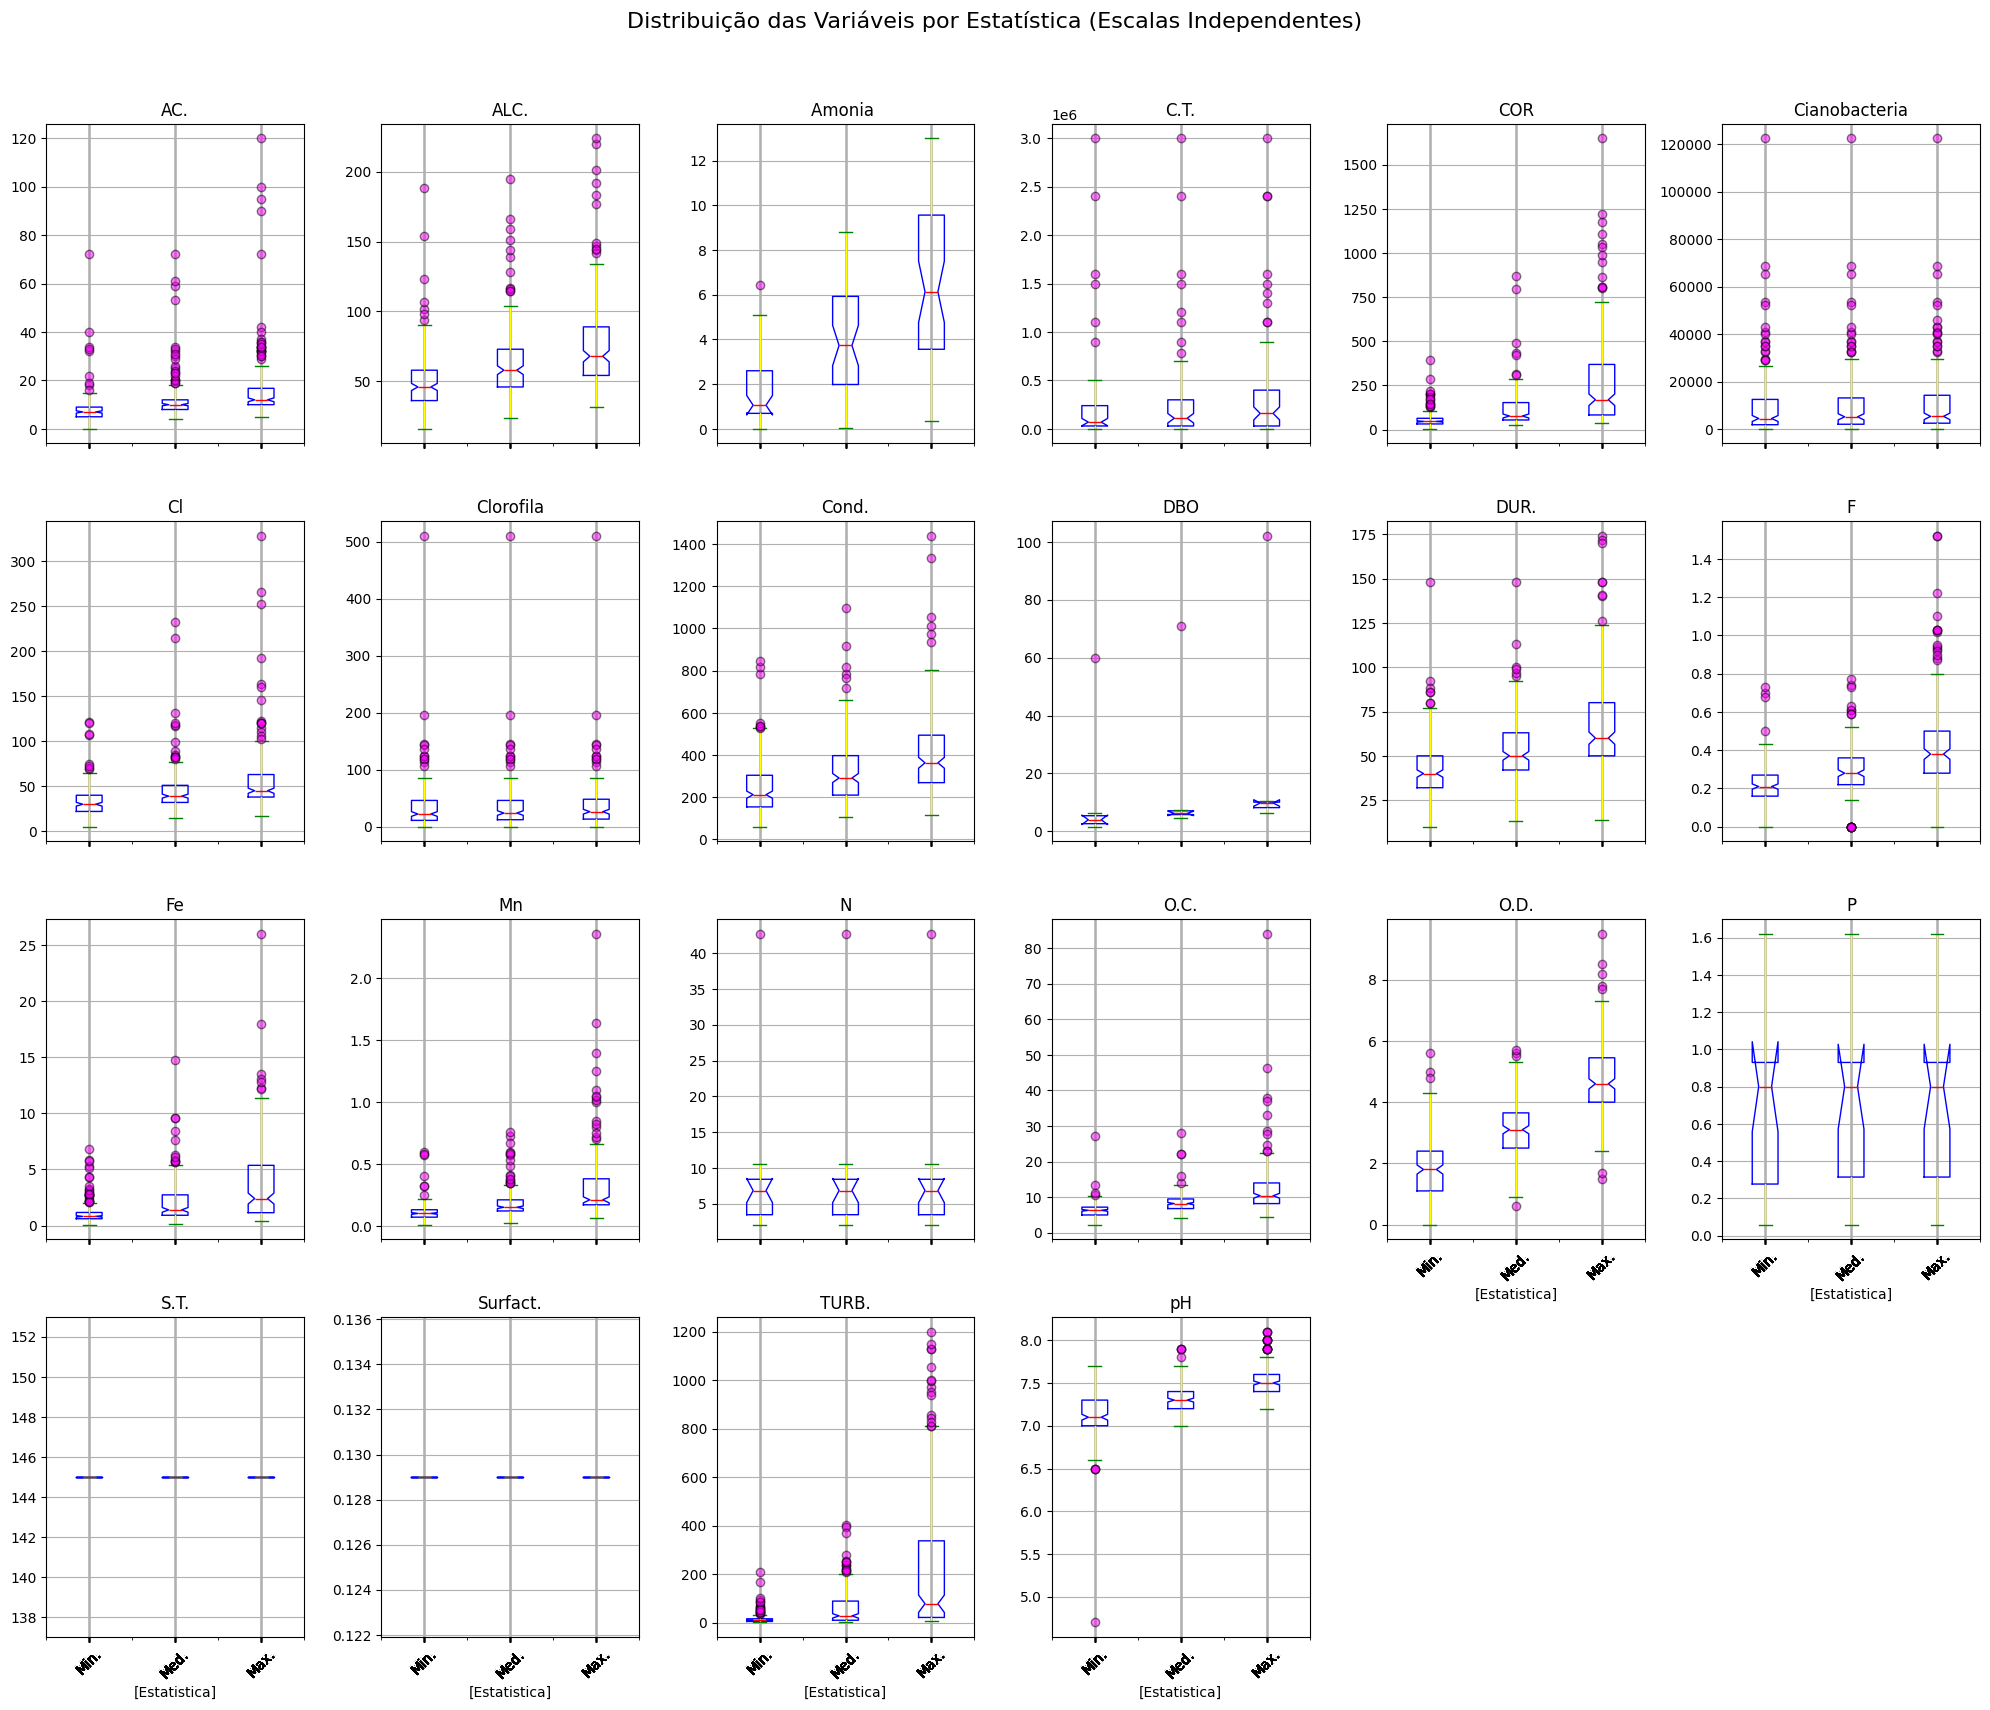

In [ ]:
dados.boxplot(by='Estatistica',             # Agrupa os dados por Estatística
            layout=(5, 6),                  # Organiza os boxplots em linhas e colunas
            figsize=(20,20),                # Determina o tamanho da figura
            sharey = False,                 # Faz com que diferentes variáveis apresentem diferentes escalas (mais apropriadas para cada uma)
            rot = 45,                       # Rotaciona os rótulos para evitar sobreposição
            color = cores_customizadas,     # Aplica as cores escolhidas
            flierprops = estilo_outliers,
            notch = True,
            )   # Aplica a formatação dos outliers escolhida
plt.suptitle('Distribuição das Variáveis por Estatística (Escalas Independentes)', fontsize=16, y=1.02)

# Ajusta o espaçamento entre os gráficos para não ficarem grudados
plt.tight_layout()

In [ ]:
### Criando variaveis contendo cada tipo de estatistica (Min, Med, Max)

cols_min = [coluna for coluna in dados_prontos.columns if coluna.endswith('Min.')] 

cols_med = [coluna for coluna in dados_prontos.columns if coluna.endswith('Med.')] 

cols_max = [coluna for coluna in dados_prontos.columns if coluna.endswith('Max.')] 

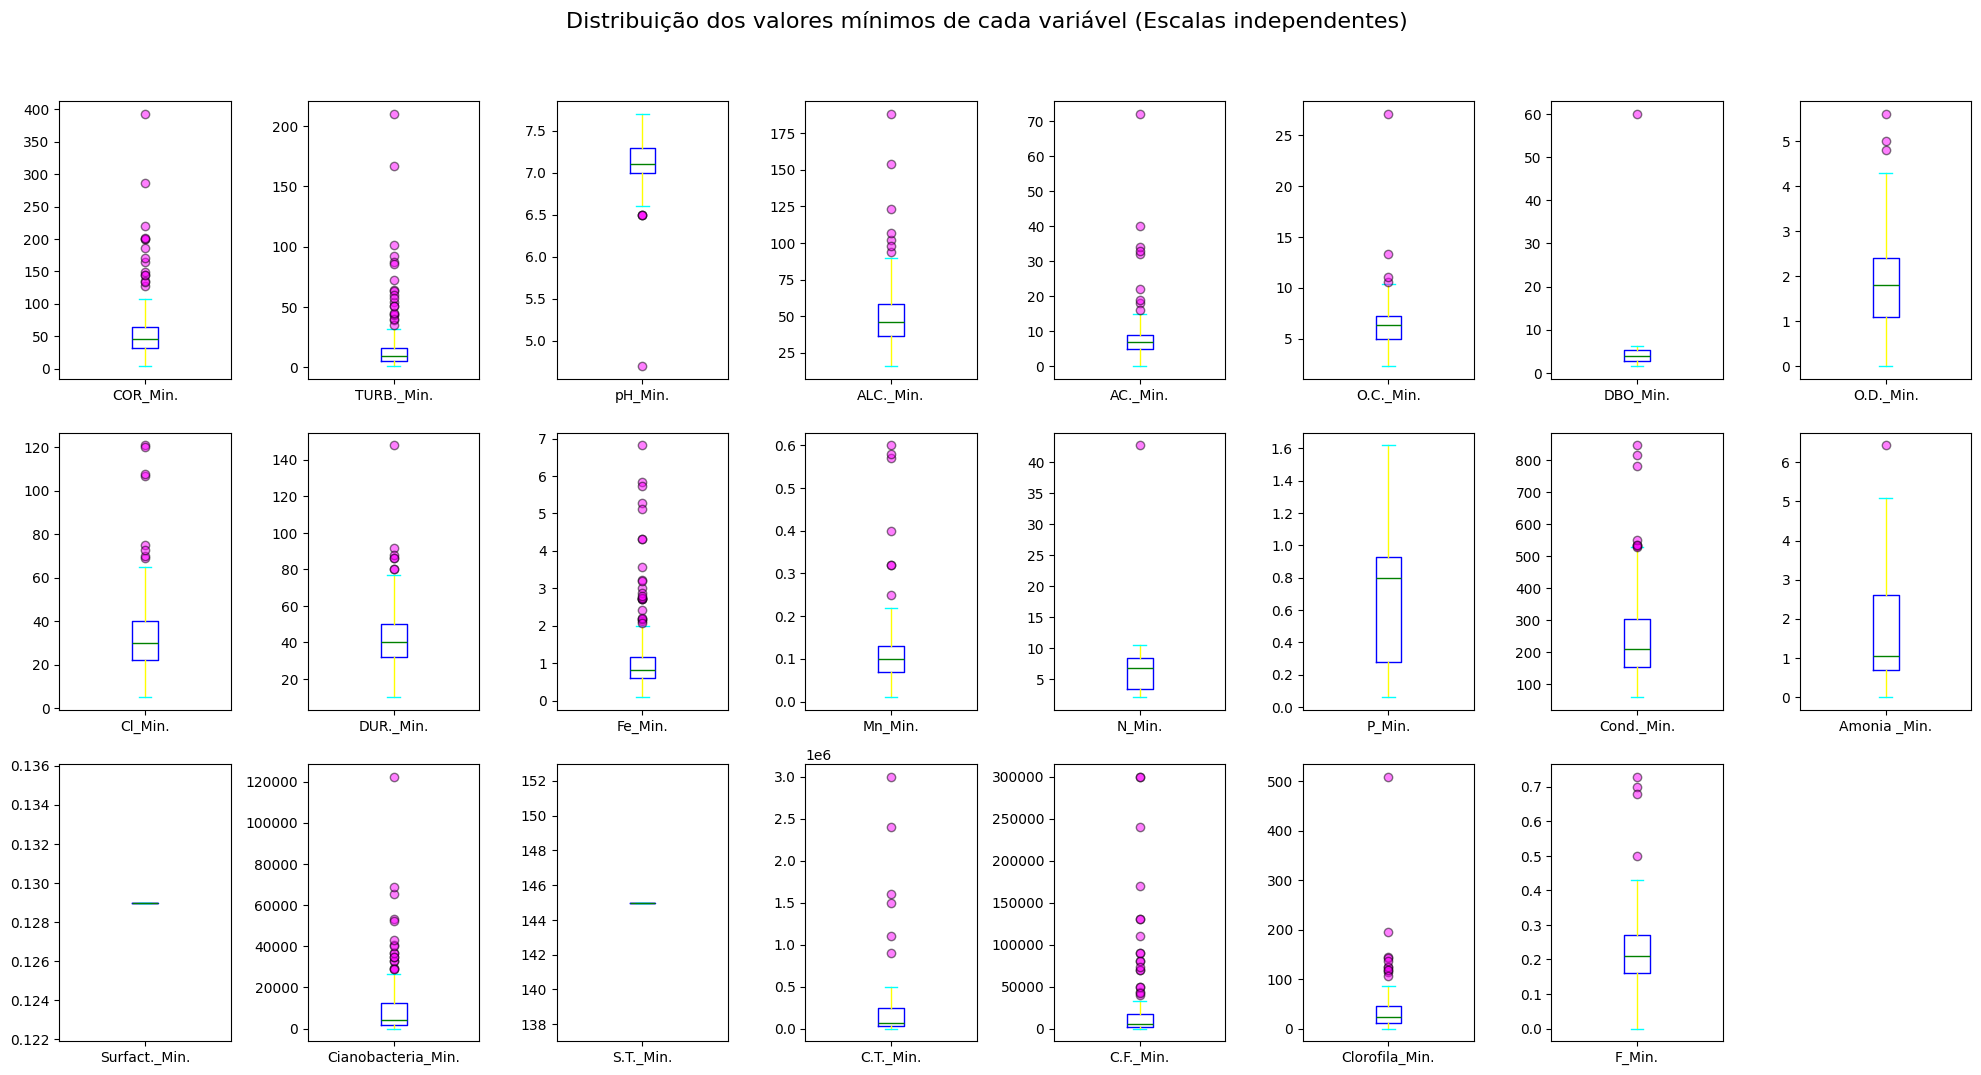

In [ ]:
ax_min = dados_prontos[cols_min].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores mínimos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()

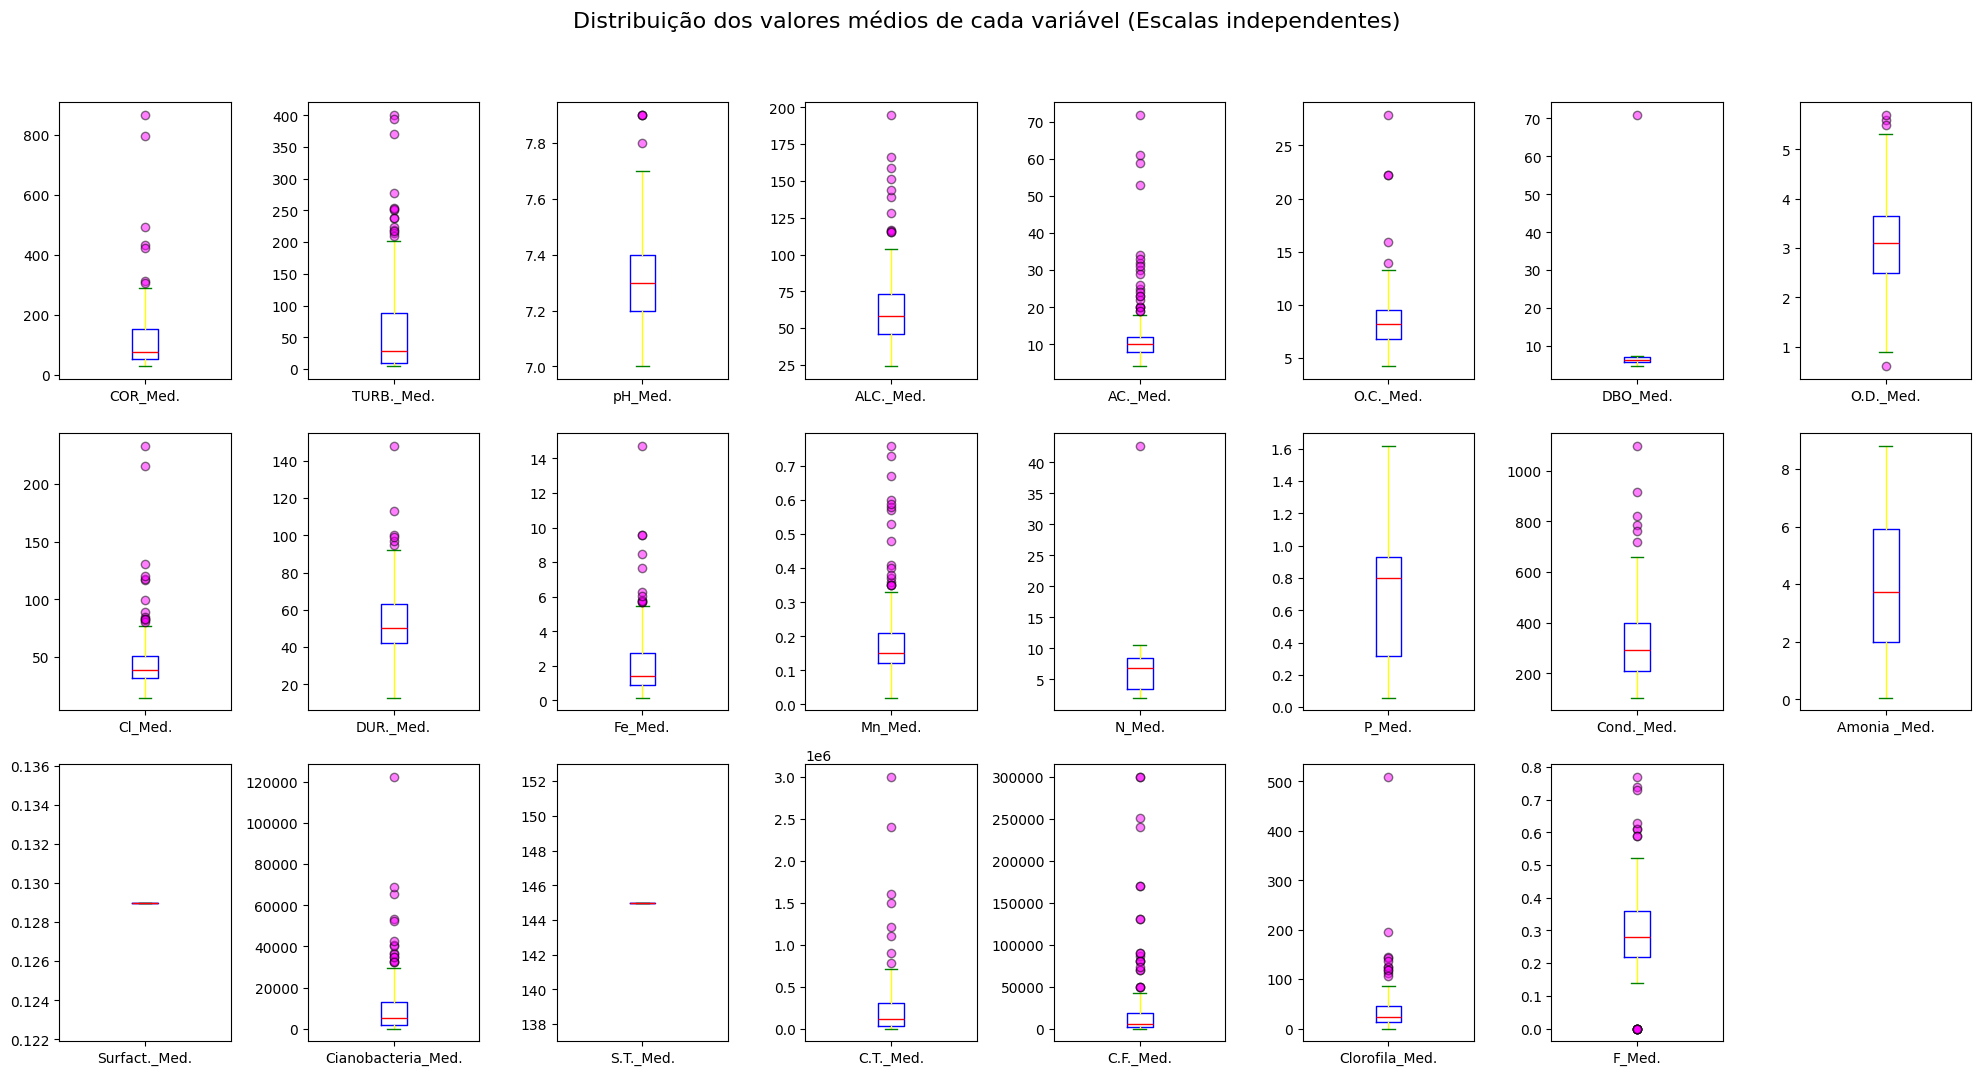

In [ ]:
ax_med = dados_prontos[cols_med].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores médios de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()

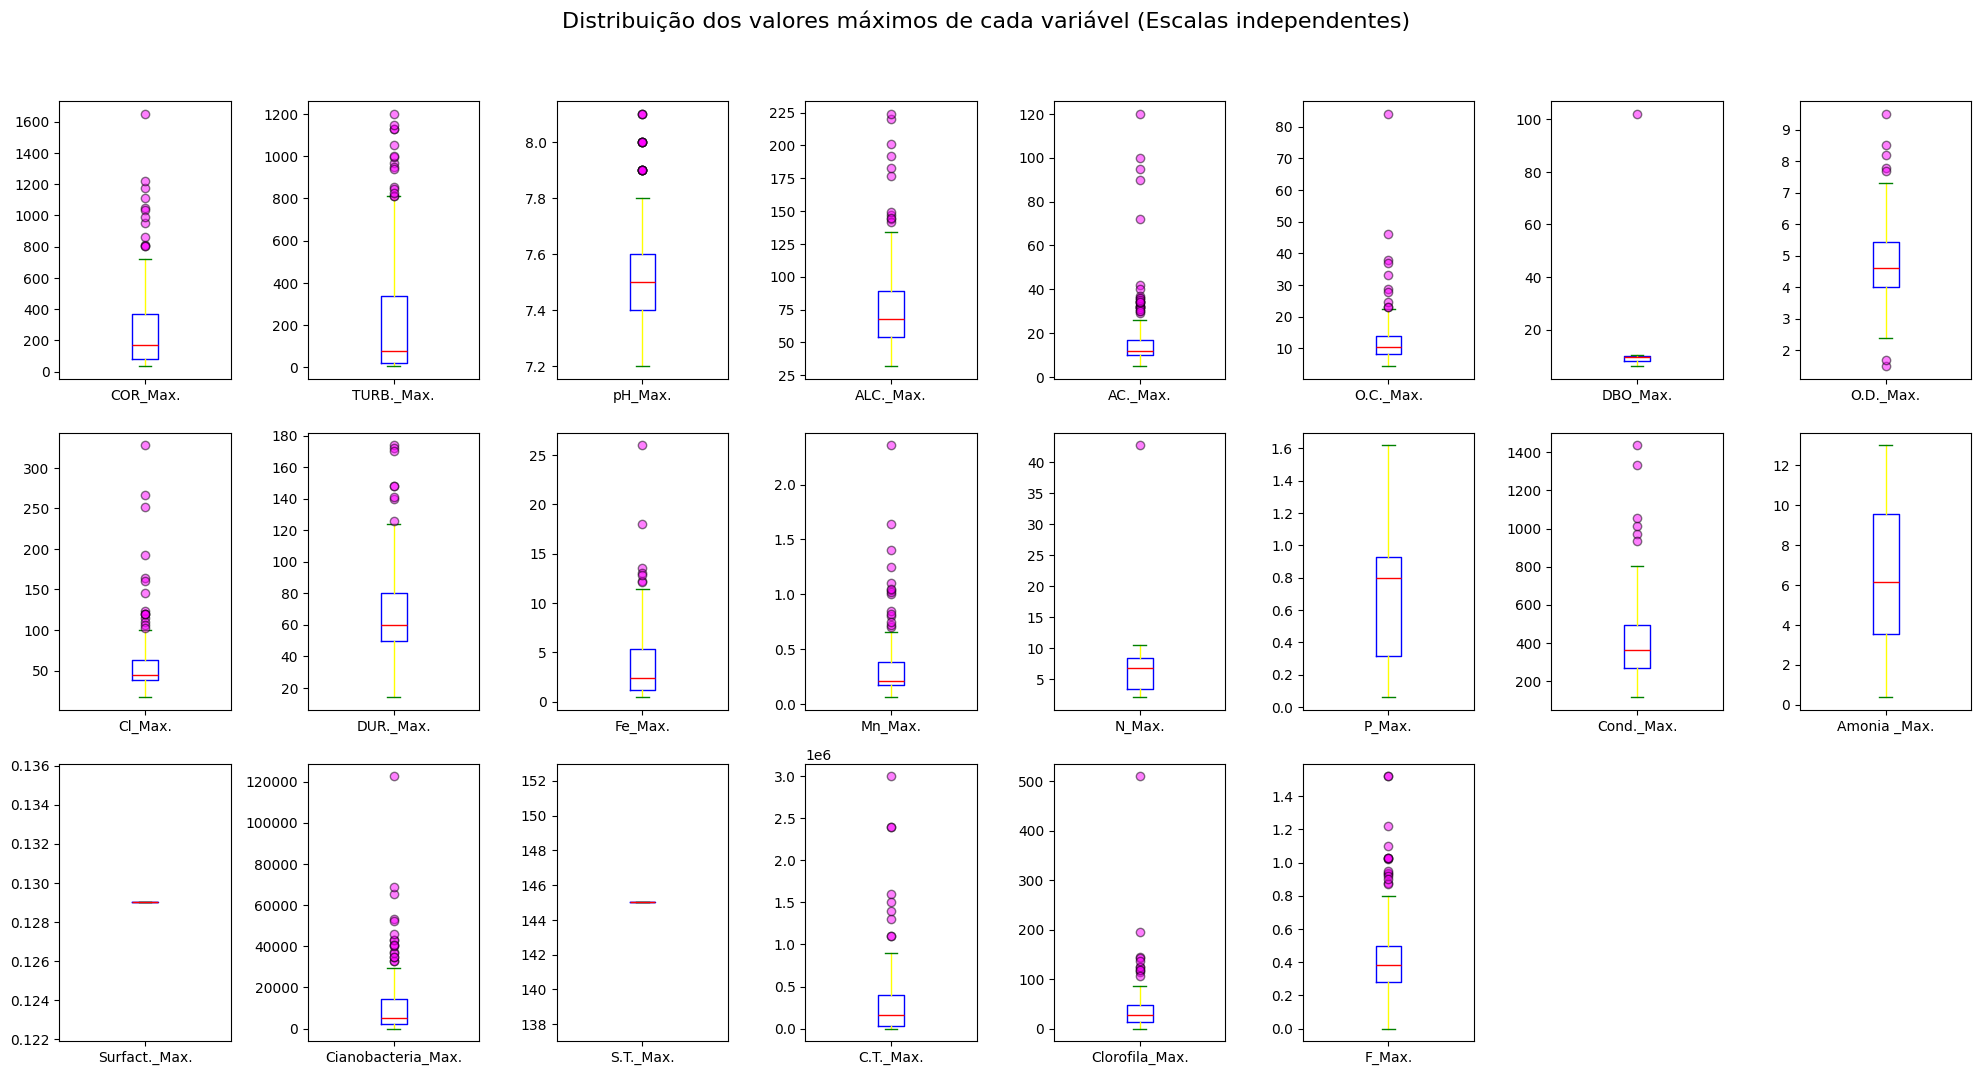

In [ ]:
ax_max = dados_prontos[cols_max].plot(kind='box',
                                subplots=True,
                                layout=(6,8),
                                figsize=(20,20),
                                sharey=False,
                                color = cores_customizadas,
                                flierprops = estilo_outliers
                                )
plt.suptitle('Distribuição dos valores máximos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

plt.tight_layout()